# Do malignant breast tumors differ in mean cell symmetry from benign ones?

Two-sample t-test, 95% confidence interval and Cohen's d on the Breast Cancer Wisconsin (Diagnostic) dataset.

## Load the data

In [1]:
import pandas as pd
df = pd.read_csv("data/breast-cancer-wisconsin.csv")
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


## Descriptive statistics

In [2]:
# descriptive stats functions, written from scratch
def my_mean(data):
    sumtotal = 0
    n = len(data)
    for element in data:
        sumtotal += element
    return sumtotal/n

def my_median(data):
    sorted_data = sorted(data) # sort data so median works for unsorted input
    n = len(sorted_data) # substitute 'data' with 'sorted_data'
    if n % 2 == 1:
        return sorted_data[n//2]
    else:
        middle_1, middle_2 = n//2 - 1, n//2
        return (sorted_data[middle_1] + sorted_data[middle_2]) / 2

def my_count(data, item):
    occurences = 0
    for element in data:
        if element == item:
            occurences += 1
    return occurences

def my_mode(data): # handling case with all unique values and no mode
    appearances = {} # add dictionary to store appearances of unique values
    for element in data:
        appearances[element] = appearances.get(element, 0) + 1
    max_appearances = max(appearances.values())
    modes = [k for k, v in appearances.items() if v == max_appearances]
    if len(modes) == len(appearances):
        return "No mode" # return 'no mode' if all values appear equally often
    elif len(modes) == 1:
        return modes[0] # return the mode
    else:
        return modes # return list of modes

def my_sample_SD(data):
    n = len(data)
    if n < 2: # avoiding zero divission error
        return 0
    sum_of_squares = 0
    mean = my_mean(data)
    for element in data:
        sum_of_squares += (element - mean)**2
    return (sum_of_squares/(n-1))**0.5

def my_range(data):
    sorted_data = sorted(data) # sort data for correct range calculation
    return sorted_data[-1] - sorted_data[0]

In [3]:
# call the functions and print the stats here
m_symmetry = df[df['diagnosis'] == 'M']['symmetry_mean']
b_symmetry = df[df['diagnosis'] == 'B']['symmetry_mean']

data = {
    'Stats': ['count', 'mean', 'median', 'mode', 'SD', 'range'],
    'Malignant': [len(m_symmetry), round(my_mean(m_symmetry), 4), round(my_median(m_symmetry), 4), my_mode(m_symmetry), round(my_sample_SD(m_symmetry),4), round(my_range(m_symmetry),4)],
    'Benign': [len(b_symmetry), round(my_mean(b_symmetry), 4), round(my_median(b_symmetry), 4), my_mode(b_symmetry), round(my_sample_SD(b_symmetry),4),round(my_range(b_symmetry),4)]
}
dataa = pd.DataFrame(data)
print(dataa)
print(f"\nMean difference (M - B) = {round(my_mean(m_symmetry) - my_mean(b_symmetry),4)}")

    Stats         Malignant            Benign
0   count               212               357
1    mean            0.1929            0.1742
2  median            0.1899            0.1714
3    mode  [0.1953, 0.1893]  [0.1714, 0.1601]
4      SD            0.0276            0.0248
5   range            0.1732            0.1683

Mean difference (M - B) = 0.0187


## Distributions

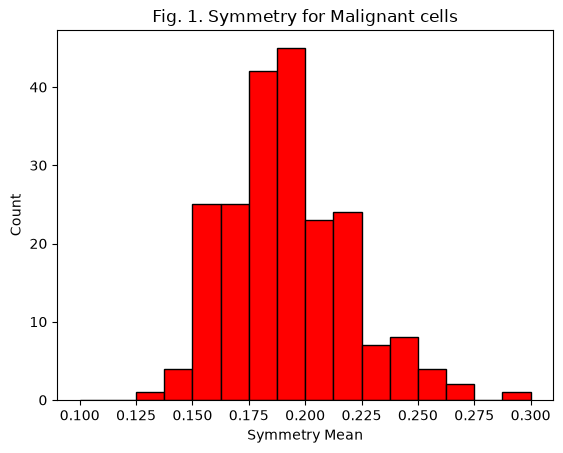

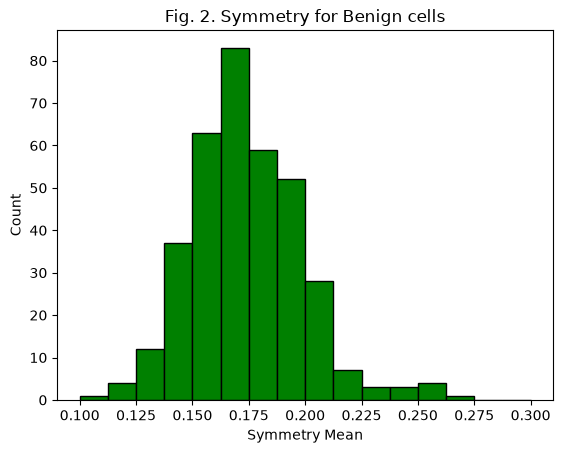

In [4]:
import matplotlib.pyplot as plt

bins=[0.1,0.1125,0.125,0.1375,0.15,0.1625,0.175,0.1875,0.2,0.2125,0.225,0.2375,0.25,0.2625,0.275,0.2875,0.3]
plt.figure()
plt.hist(m_symmetry, bins=bins, edgecolor="black", color="red")
plt.xlabel('Symmetry Mean')
plt.ylabel('Count')
plt.title('Fig. 1. Symmetry for Malignant cells')
plt.show()

plt.figure()
plt.hist(b_symmetry, bins=bins, edgecolor="black", color="green")
plt.xlabel('Symmetry Mean')
plt.ylabel('Count')
plt.title('Fig. 2. Symmetry for Benign cells')
plt.show()

## Hypothesis test

In [5]:
# two-sample t-test to assess whether the population mean of symmetry_mean differs between malignant and benign tumors

import numpy as np
from scipy import stats

sym_m = m_symmetry.to_numpy()
sym_b = b_symmetry.to_numpy()

alpha = 0.05 # significance level

t_stat, p_value = stats.ttest_ind(sym_m, sym_b)

if p_value < alpha:
  decision = "reject H0"
else:
  decision = "fail to reject H0"

print(f"t = {t_stat:.4f}, p = {p_value:.4e}")
print(f"alpha = {alpha} → decision: {decision}")

t = 8.3383, p = 5.7334e-16
alpha = 0.05 → decision: reject H0


## Confidence interval

In [6]:
# stats for further calculations
mean_m, std_m, n_m = my_mean(m_symmetry), my_sample_SD(m_symmetry), len(m_symmetry)
mean_b, std_b, n_b = my_mean(b_symmetry), my_sample_SD(b_symmetry), len(b_symmetry)

# calculate standard error
se_diff = np.sqrt(((std_m**2) / n_m) + ((std_b**2) / n_b))

# degrees of freedom
dof = n_m + n_b - 2

# t-critical value
# we need 95% confidence, so alpha = 0.05.
# We need the 97.5th percentile point (because 2.5% is in each tail).
alpha = 0.05
t_critical = stats.t.ppf(1 - (alpha/2), dof)

# calculate margin of error and bounds
mean_diff = mean_m - mean_b
margin_of_error = t_critical * se_diff

lower_bound = mean_diff - margin_of_error
upper_bound = mean_diff + margin_of_error

# output
print(f"Mean Difference: {mean_diff:.4f}")
print(f"t-critical:      {t_critical:.4f}")
print(f"Standard Error:  {se_diff:.4f}")
print(f"95% CI:          [{lower_bound:.4f}, {upper_bound:.4f}]")

Mean Difference: 0.0187
t-critical:      1.9642
Standard Error:  0.0023
95% CI:          [0.0142, 0.0233]


## Effect size

In [7]:
# calculate Cohen's d (effect size)
x = sym_m
y = sym_b
nx = len(x)
ny = len(y)
dof = nx + ny - 2
pool_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
d = (np.mean(x) - np.mean(y)) / pool_std

print("Effect Size")
print(f"Cohen's d: {d:.4f}")
if abs(d) < 0.2:
  print("Magnitude: Negligible")
elif abs(d) < 0.5:
  print("Magnitude: Small")
elif abs(d) < 0.8:
  print("Magnitude: Medium")
else:
  print("Magnitude: Large")

Effect Size
Cohen's d: 0.7230
Magnitude: Medium
